In [3]:
# DAY 19 - BOOSTING MODEL PERFORMANCE WITH XGBOOST

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from xgboost import XGBClassifier

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 912.1 kB/s eta 0:00:54
   ---------------------------------------- 0.5/48.9 MB 912.1 kB/s eta 0:00:54
    --------------------------------------- 0.8/48.9 MB 856.1 kB/s eta 0:00:57
   - -------------------------------------- 1.3/48.9 MB 1.1 MB/s eta 0:00:42
   - -------------------------------------- 1.6/48.9 MB 1.3 MB/s eta 0:00:38
   - -------------------------------------- 2.1/48.9 MB 1.5 MB/s eta 0:00:32
   -- ------------------------------------- 2.6/48.9 MB 1.6 MB/s eta 0:00:30
   -- ------------------------------------- 3.1/48.9 MB 1.7 MB/s eta 0:00:28
   --- -------------

In [4]:
# Create fraud detection dataset

data = {
    "Transaction_Amount": [
        120, 250, 80, 5000, 150, 75, 3000, 200, 450, 7000,
        90, 180, 2500, 130, 6000
    ],

    "Transaction_Frequency": [
        2, 3, 1, 15, 2, 1, 12, 3, 4, 20,
        1, 2, 10, 2, 18
    ],

    "Account_Age_Days": [
        800, 600, 1000, 30, 700, 900, 45, 500, 400, 20,
        1200, 750, 60, 650, 25
    ],

    "International_Transaction": [
        0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
        0, 0, 1, 0, 1
    ],

    "Fraud": [
        0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
        0, 0, 1, 0, 1
    ]
}

fraud_data = pd.DataFrame(data)

print("Dataset created successfully!")
print(fraud_data)

Dataset created successfully!
    Transaction_Amount  Transaction_Frequency  Account_Age_Days  \
0                  120                      2               800   
1                  250                      3               600   
2                   80                      1              1000   
3                 5000                     15                30   
4                  150                      2               700   
5                   75                      1               900   
6                 3000                     12                45   
7                  200                      3               500   
8                  450                      4               400   
9                 7000                     20                20   
10                  90                      1              1200   
11                 180                      2               750   
12                2500                     10                60   
13                 130          

In [5]:
X = fraud_data[
    [
        "Transaction_Amount",
        "Transaction_Frequency",
        "Account_Age_Days",
        "International_Transaction"
    ]
]

y = fraud_data["Fraud"]

print("Features:")
print(X)

print("\nTarget:")
print(y)

Features:
    Transaction_Amount  Transaction_Frequency  Account_Age_Days  \
0                  120                      2               800   
1                  250                      3               600   
2                   80                      1              1000   
3                 5000                     15                30   
4                  150                      2               700   
5                   75                      1               900   
6                 3000                     12                45   
7                  200                      3               500   
8                  450                      4               400   
9                 7000                     20                20   
10                  90                      1              1200   
11                 180                      2               750   
12                2500                     10                60   
13                 130                      2       

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (12, 4)
Testing data: (3, 4)


In [7]:
# Train Random Forest

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=3
)

random_forest.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [8]:
# Train XGBoost

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [9]:
# Make predictions

rf_pred = random_forest.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

print("Random Forest Predictions:")
print(rf_pred)

print("\nXGBoost Predictions:")
print(xgb_pred)

print("\nActual Values:")
print(y_test.values)

Random Forest Predictions:
[0 1 0]

XGBoost Predictions:
[0 1 1]

Actual Values:
[0 1 0]


In [10]:
# Compare model accuracy

rf_accuracy = accuracy_score(y_test, rf_pred)
xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("Random Forest Accuracy:", round(rf_accuracy, 3))
print("XGBoost Accuracy:", round(xgb_accuracy, 3))

Random Forest Accuracy: 1.0
XGBoost Accuracy: 0.667


In [11]:
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nXGBoost Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

Random Forest Confusion Matrix:
[[2 0]
 [0 1]]

XGBoost Confusion Matrix:
[[1 1]
 [0 1]]


In [12]:
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred, zero_division=0))

print("\nXGBoost Classification Report:")
print(classification_report(y_test, xgb_pred, zero_division=0))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



In [13]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "XGBoost"],
    "Accuracy": [
        0,  # we will replace this
        rf_accuracy,
        xgb_accuracy
    ]
})

print(comparison)

           Model  Accuracy
0  Decision Tree  0.000000
1  Random Forest  1.000000
2        XGBoost  0.666667


In [14]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_accuracy, xgb_accuracy]
})

print(comparison)

comparison.to_csv("model_comparison.csv", index=False)

print("\nModel comparison saved successfully!")

           Model  Accuracy
0  Random Forest  1.000000
1        XGBoost  0.666667

Model comparison saved successfully!


In [15]:
# XGBoost Feature Importance

xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(xgb_importance)

                     Feature  Importance
0         Transaction_Amount    0.529438
2           Account_Age_Days    0.470562
1      Transaction_Frequency    0.000000
3  International_Transaction    0.000000


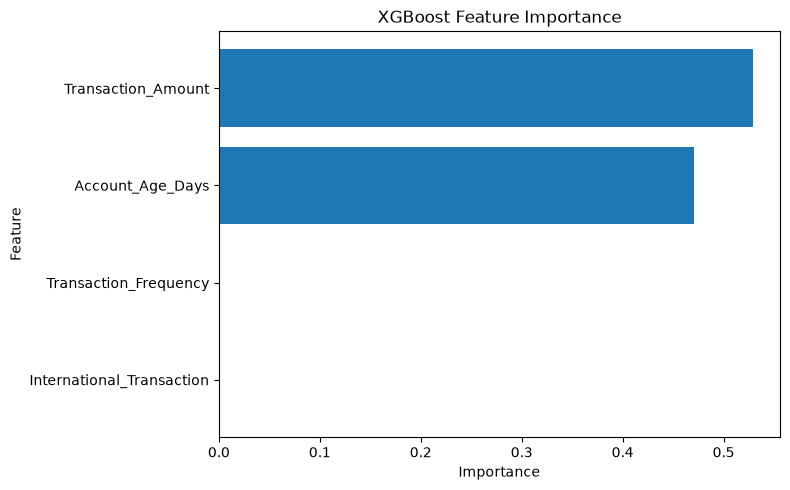

In [16]:
plt.figure(figsize=(8, 5))

plt.barh(
    xgb_importance["Feature"],
    xgb_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("xgboost_feature_importance.png")
plt.show()

In [17]:
# Check XGBoost training vs testing accuracy

xgb_train_accuracy = xgb_model.score(X_train, y_train)
xgb_test_accuracy = xgb_model.score(X_test, y_test)

print("XGBoost Training Accuracy:", round(xgb_train_accuracy, 3))
print("XGBoost Testing Accuracy:", round(xgb_test_accuracy, 3))

XGBoost Training Accuracy: 1.0
XGBoost Testing Accuracy: 0.667


In [18]:
# Save XGBoost prediction results

results = X_test.copy()

results["Actual_Fraud"] = y_test.values
results["RF_Predicted"] = rf_pred
results["XGB_Predicted"] = xgb_pred

results.to_csv("fraud_predictions.csv", index=False)

print("Prediction results saved successfully!")
print(results)

Prediction results saved successfully!
   Transaction_Amount  Transaction_Frequency  Account_Age_Days  \
4                 150                      2               700   
9                7000                     20                20   
8                 450                      4               400   

   International_Transaction  Actual_Fraud  RF_Predicted  XGB_Predicted  
4                          0             0             0              0  
9                          1             1             1              1  
8                          0             0             0              1  


In [19]:
# XGBoost Advantages and Trade-offs

print("XGBoost Advantages and Trade-offs")

print("1. Boosting improves the model step-by-step.")
print("2. XGBoost can capture complex relationships in data.")
print("3. It performs well on structured/tabular datasets.")
print("4. It can overfit if the model becomes too complex.")
print("5. It requires more tuning than a simple Decision Tree.")

XGBoost Advantages and Trade-offs
1. Boosting improves the model step-by-step.
2. XGBoost can capture complex relationships in data.
3. It performs well on structured/tabular datasets.
4. It can overfit if the model becomes too complex.
5. It requires more tuning than a simple Decision Tree.


In [20]:
# Day 19 final summary

print("Day 19 - Boosting Model Performance with XGBoost")
print("Trained a Random Forest model.")
print("Trained an XGBoost boosting model.")
print("Compared both model performances.")
print("Analyzed XGBoost feature importance.")
print("Checked training and testing accuracy.")
print("Documented boosting advantages and trade-offs.")
print("Note: Dataset is synthetic and created for learning.")

Day 19 - Boosting Model Performance with XGBoost
Trained a Random Forest model.
Trained an XGBoost boosting model.
Compared both model performances.
Analyzed XGBoost feature importance.
Checked training and testing accuracy.
Documented boosting advantages and trade-offs.
Note: Dataset is synthetic and created for learning.
